# Modelos no supervisados: K-Means y DBSCAN

En este notebook se exploran técnicas no supervisadas para detectar estructuras anómalas en las transacciones. A diferencia del modelado supervisado, aquí **no se utiliza la etiqueta `fraud` durante el entrenamiento**.

La etiqueta solo se carga al final de forma opcional para interpretar si los grupos encontrados concentran más fraude que la media del dataset.

## Librerías y configuración

In [6]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.cluster import DBSCAN, KMeans, MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
SAMPLE_SIZE = 50000
DBSCAN_SAMPLE_SIZE = 30000
N_COMPONENTS = 10

## Carga de datos sin etiqueta

`X_clean.csv` contiene las variables ya preparadas en `03_Preprocesamiento`. La variable objetivo `fraud` se mantiene separada y no participa en el ajuste de K-Means ni DBSCAN.

In [7]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "clean"
models_path = project_root / "models"
models_path.mkdir(parents=True, exist_ok=True)

X = pd.read_csv(data_path / "X_clean.csv")
y = pd.read_csv(data_path / "y.csv").squeeze("columns")

print("X:", X.shape)
print("y cargada solo para análisis posterior:", y.shape)
display(X.head())

X: (594643, 10)
y cargada solo para análisis posterior: (594643,)


,customer,age,gender,merchant,category,amount,high_amount,day_of_week_sin,day_of_week_cos,merchant_freq
0,'C1093826151',4,M,'M348934600','es_transportation',4.55,0,0.0,1.0,205426
1,'C352968107',2,M,'M348934600','es_transportation',39.68,0,0.0,1.0,205426
2,'C2054744914',4,F,'M1823072687','es_transportation',26.89,0,0.0,1.0,299693
3,'C1760612790',3,M,'M348934600','es_transportation',17.25,0,0.0,1.0,205426
4,'C757503768',5,M,'M348934600','es_transportation',35.72,0,0.0,1.0,205426


## Preprocesamiento

Se codifican variables categóricas con one-hot y se escalan las numéricas. Este preprocesamiento se ajusta solo sobre `X`, sin etiquetas.

In [8]:
cat_cols = ["customer", "age", "gender", "merchant", "category"]
num_cols = [col for col in X.columns if col not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=20,
                sparse_output=True,
            ),
            cat_cols,
        ),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop",
)

print("Categóricas:", cat_cols)
print("Numéricas:", num_cols)

Categóricas: ['customer', 'age', 'gender', 'merchant', 'category']
Numéricas: ['amount', 'high_amount', 'day_of_week_sin', 'day_of_week_cos', 'merchant_freq']


## Muestra de trabajo

K-Means puede ejecutarse sobre todo el dataset, pero algunas métricas internas y DBSCAN son costosas con casi 600k filas. Por eso se usa una muestra reproducible para selección y evaluación exploratoria.

In [9]:
sample_size = min(SAMPLE_SIZE, len(X))
sample_idx = X.sample(n=sample_size, random_state=RANDOM_STATE).index
X_sample = X.loc[sample_idx].copy()
y_sample = y.loc[sample_idx].copy()

print("Muestra:", X_sample.shape)
print("Fraude en muestra solo para interpretación posterior:", round(y_sample.mean() * 100, 3), "%")

Muestra: (50000, 10)
Fraude en muestra solo para interpretación posterior: 1.182 %


## K-Means

Se prueba un rango de valores de `k`. Para un dataset grande y disperso por one-hot encoding se usa `MiniBatchKMeans`, una variante escalable de K-Means. La selección se apoya en inertia, silhouette, Calinski-Harabasz y Davies-Bouldin.

In [10]:
k_values = [2, 3, 4, 5, 6, 8, 10]
kmeans_results = []

X_sample_prepared = preprocessor.fit_transform(X_sample)
metric_svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_sample_metric = metric_svd.fit_transform(X_sample_prepared)

print("Varianza explicada SVD para métricas:", round(metric_svd.explained_variance_ratio_.sum(), 4))

for k in k_values:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        batch_size=4096,
        n_init="auto",
    )
    labels = model.fit_predict(X_sample_prepared)

    sil = silhouette_score(
        X_sample_metric,
        labels,
        sample_size=min(10000, X_sample_metric.shape[0]),
        random_state=RANDOM_STATE,
    )

    kmeans_results.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": sil,
            "calinski_harabasz": calinski_harabasz_score(X_sample_metric, labels),
            "davies_bouldin": davies_bouldin_score(X_sample_metric, labels),
        }
    )

kmeans_results_df = pd.DataFrame(kmeans_results)
display(kmeans_results_df.sort_values("silhouette", ascending=False))

Varianza explicada SVD para métricas: 0.9048


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,296563.100476,0.559789,13817.923209,0.861331
6,10,164696.218511,0.244290,8835.361516,1.362197
3,5,200221.970104,0.234611,12765.224596,1.312603
4,6,191884.939991,0.218477,11340.700223,1.361036
5,8,185960.079922,0.207882,8693.987547,1.480976
2,4,230951.493386,0.201216,11740.347147,1.471152
1,3,258633.894351,0.198109,12332.662885,1.665925


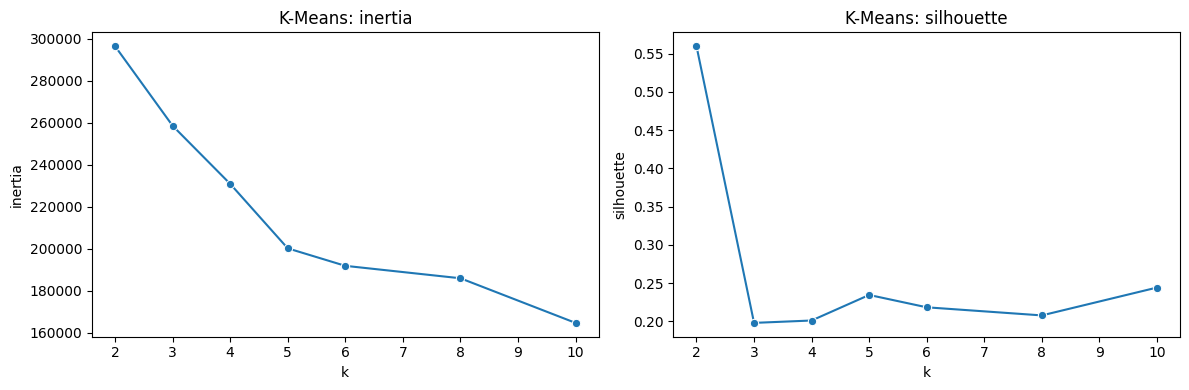

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=kmeans_results_df, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("K-Means: inertia")
sns.lineplot(data=kmeans_results_df, x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].set_title("K-Means: silhouette")
plt.tight_layout()
plt.show()

## Ajuste final de K-Means

Se selecciona automáticamente el `k` con mayor silhouette en la muestra y se ajusta un pipeline sobre todo `X`, sin usar `fraud`. Después se analiza la distribución de fraude por cluster solo como interpretación posterior.

In [12]:
best_k = int(kmeans_results_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Mejor k según silhouette:", best_k)

kmeans_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "cluster",
            MiniBatchKMeans(
                n_clusters=best_k,
                random_state=RANDOM_STATE,
                batch_size=4096,
                n_init="auto",
            ),
        ),
    ]
)

kmeans_labels = kmeans_pipeline.fit_predict(X)

kmeans_profile = (
    pd.DataFrame({"cluster": kmeans_labels, "fraud": y})
    .groupby("cluster")
    .agg(
        n=("fraud", "size"),
        frauds=("fraud", "sum"),
        fraud_rate=("fraud", "mean"),
    )
    .sort_values("fraud_rate", ascending=False)
)
kmeans_profile["fraud_rate"] = (kmeans_profile["fraud_rate"] * 100).round(3)
display(kmeans_profile)

joblib.dump(kmeans_pipeline, models_path / "kmeans_unsupervised_pipeline.joblib")
print("K-Means guardado en:", models_path / "kmeans_unsupervised_pipeline.joblib")

Mejor k según silhouette: 2


,n,frauds,fraud_rate
cluster,,,
1,29732,6266,21.075
0,564911,934,0.165


K-Means guardado en: /Users/aldan/Desktop/tfg_code/models/kmeans_unsupervised_pipeline.joblib


## DBSCAN

DBSCAN busca zonas densas y marca como `-1` los puntos considerados ruido. En este dataset, aplicar DBSCAN directamente al one-hot de alta dimensión no suele ser recomendable, por lo que primero se reduce dimensionalidad con `TruncatedSVD` y se trabaja con una muestra.

In [13]:
dbscan_sample_size = min(DBSCAN_SAMPLE_SIZE, len(X))
dbscan_idx = X.sample(n=dbscan_sample_size, random_state=RANDOM_STATE).index
X_dbscan = X.loc[dbscan_idx].copy()
y_dbscan = y.loc[dbscan_idx].copy()

preprocessor_dbscan = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=20,
                sparse_output=True,
            ),
            cat_cols,
        ),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop",
)

X_dbscan_prepared = preprocessor_dbscan.fit_transform(X_dbscan)
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_dbscan_reduced = svd.fit_transform(X_dbscan_prepared)

print("Muestra DBSCAN:", X_dbscan.shape)
print("Varianza explicada SVD:", round(svd.explained_variance_ratio_.sum(), 4))

Muestra DBSCAN: (30000, 10)
Varianza explicada SVD: 0.9254


In [14]:
dbscan_configs = [
    {"eps": 0.5, "min_samples": 20},
    {"eps": 0.8, "min_samples": 20},
    {"eps": 1.0, "min_samples": 30},
    {"eps": 1.5, "min_samples": 30},
]

dbscan_results = []
dbscan_labels_by_config = {}

for params in dbscan_configs:
    model = DBSCAN(**params, n_jobs=-1)
    labels = model.fit_predict(X_dbscan_reduced)
    tag = f"eps={params['eps']}_min={params['min_samples']}"
    dbscan_labels_by_config[tag] = labels

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_rate = (labels == -1).mean()

    dbscan_results.append(
        {
            "config": tag,
            "eps": params["eps"],
            "min_samples": params["min_samples"],
            "n_clusters": n_clusters,
            "noise_rate": noise_rate,
            "fraud_rate_noise": y_dbscan[labels == -1].mean() if (labels == -1).any() else np.nan,
        }
    )

dbscan_results_df = pd.DataFrame(dbscan_results)
dbscan_results_df["noise_rate"] = (dbscan_results_df["noise_rate"] * 100).round(3)
dbscan_results_df["fraud_rate_noise"] = (dbscan_results_df["fraud_rate_noise"] * 100).round(3)
display(dbscan_results_df)

,config,eps,min_samples,n_clusters,noise_rate,fraud_rate_noise
0,eps=0.5_min=20,0.5,20,182,4.093,23.371
1,eps=0.8_min=20,0.8,20,124,2.037,39.280
2,eps=1.0_min=30,1.0,30,35,1.207,58.564
3,eps=1.5_min=30,1.5,30,4,0.800,52.917


## Interpretación no supervisada

K-Means es útil para segmentar transacciones y comprobar si ciertos clusters concentran una tasa de fraude superior a la media. Si un cluster tiene una tasa de fraude claramente mayor, puede usarse como feature adicional en un modelo supervisado o como señal de riesgo.

DBSCAN es más apropiado como detector exploratorio de ruido/anomalía. Si los puntos con etiqueta `-1` muestran una tasa de fraude mayor que la media, entonces el ruido de DBSCAN captura comportamiento sospechoso. Si no ocurre, DBSCAN no está aportando una señal útil con esta representación.

Importante: estos modelos no sustituyen al enfoque supervisado, porque no optimizan directamente la detección de fraude. Sirven como análisis complementario y posible generación de variables.

In [15]:
dbscan_ranking = dbscan_results_df.copy()
dbscan_ranking["fraud_rate_noise_rank"] = dbscan_ranking["fraud_rate_noise"].fillna(-1)

best_dbscan_row = dbscan_ranking.sort_values(
    ["fraud_rate_noise_rank", "noise_rate"],
    ascending=[False, True],
).iloc[0]
best_dbscan_tag = best_dbscan_row["config"]
best_dbscan_labels = dbscan_labels_by_config[best_dbscan_tag]

print("Mejor configuración exploratoria DBSCAN:", best_dbscan_tag)
print("Tasa de fraude global en muestra DBSCAN:", round(y_dbscan.mean() * 100, 3), "%")
print("Tasa de fraude en ruido DBSCAN:", best_dbscan_row["fraud_rate_noise"], "%")

# Guardamos objetos necesarios para reproducir DBSCAN sobre la muestra.
dbscan_artifact = {
    "preprocessor": preprocessor_dbscan,
    "svd": svd,
    "config": best_dbscan_tag,
    "labels": best_dbscan_labels,
    "sample_index": dbscan_idx,
    "results": dbscan_results_df,
}
joblib.dump(dbscan_artifact, models_path / "dbscan_unsupervised_artifact.joblib")
print("DBSCAN guardado en:", models_path / "dbscan_unsupervised_artifact.joblib")

Mejor configuración exploratoria DBSCAN: eps=1.0_min=30
Tasa de fraude global en muestra DBSCAN: 1.18 %
Tasa de fraude en ruido DBSCAN: 58.564 %
DBSCAN guardado en: /Users/aldan/Desktop/tfg_code/models/dbscan_unsupervised_artifact.joblib
